# European Bird Sightings Analysis
## Combining and Analyzing eBird Data from 47 European Countries

This notebook will:
1. Combine all your CSV files into one dataset
2. Perform comprehensive statistical analysis
3. Create visualizations
4. Export results

---

## Setup and Imports

In [32]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime
import geopandas as gpd

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Data Preprocessing

In [33]:
combined_df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/native_species_europe_only.csv")


In [34]:
combined_df.head()

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE
0,Great Spotted Woodpecker,Dendrocopos major,1.0,NaN,Portugal,PT,Portalegre,PT-12,Castelo de Vide,PT-12-CV,NaN,PN Serra de SÃ£o Mamede--Cana Flexa,L2939710,H,39.461957,-7.511044,2018-01-26,obsr429991,S42251764,Stationary
1,Great Spotted Woodpecker,Dendrocopos major,1.0,NaN,Ukraine,UA,Kirovohrads'ka Oblast',UA-35,NaN,NaN,NaN,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,L8290442,P,49.052457,33.215695,2018-12-22,obsr1017757,S50893829,Traveling
2,Great Spotted Woodpecker,Dendrocopos major,3.0,NaN,Spain,ES,"Madrid, Comunidad de",ES-MD,NaN,NaN,NaN,LeganÃ©s--Parque Polvoranca,L4679861,H,40.325174,-3.796721,2018-01-21,obsr771146,S42131687,Traveling
3,Great Spotted Woodpecker,Dendrocopos major,5.0,NaN,Croatia,HR,Koprivnicko-kriÅ¾evacka Å¾upanija,HR-06,NaN,NaN,NaN,Hill Crkvenjak,L4575501,P,46.092728,16.558564,2018-01-06,obsr733488,S41672345,Traveling
4,Great Spotted Woodpecker,Dendrocopos major,2.0,NaN,United Kingdom,GB,Scotland,GB-SCT,Fife,GB-SCT-FIF,NaN,Kilrenny Common,L4811182,H,56.236498,-2.686082,2018-06-09,obsr407628,S46534187,Traveling


In [35]:
# Convert date column to datetime
combined_df['obsDt'] = pd.to_datetime(combined_df['OBSERVATION DATE'], errors='coerce')

# Extract temporal features
combined_df['year'] = combined_df['obsDt'].dt.year
combined_df['month'] = combined_df['obsDt'].dt.month
combined_df['day_of_week'] = combined_df['obsDt'].dt.dayofweek
combined_df['day_of_year'] = combined_df['obsDt'].dt.dayofyear

# drop 2026 (it ruins the results)
combined_df = combined_df[combined_df['year'] != 2026]

# Convert count to numeric
combined_df['howMany'] = pd.to_numeric(combined_df['OBSERVATION COUNT'], errors='coerce')

print("✓ Data preprocessing complete!")
print(f"\nDate range: {combined_df['obsDt'].min()} to {combined_df['obsDt'].max()}")
print(f"Years covered: {sorted(combined_df['year'].dropna().unique().astype(int).tolist())}")

✓ Data preprocessing complete!

Date range: 2017-01-01 00:00:00 to 2025-12-31 00:00:00
Years covered: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [36]:
combined_df = combined_df[combined_df['year'] < 2023]

## 3. Basic Statistics

In [37]:
# Overall statistics
print("="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)
print(f"\nTotal observations: {len(combined_df):,}")
print(f"Number of countries: {combined_df['COUNTRY CODE'].nunique()}")
print(f"Number of states/regions: {combined_df['STATE CODE'].nunique()}")
print(f"Number of counties: {combined_df['COUNTY CODE'].nunique()}")
print(f"Number of unique species: {combined_df['SCIENTIFIC NAME'].nunique()}")
print(f"Number of locality types: {combined_df['LOCALITY TYPE'].nunique()}")
print(f"Number of observation types: {combined_df['OBSERVATION TYPE'].nunique()}")
print(f"Number of unique observers: {combined_df['OBSERVER ID'].nunique()}")

# Count data statistics
count_data = combined_df[combined_df['howMany'].notna()]
print(f"\nObservations with count data: {len(count_data):,} ({len(count_data)/len(combined_df)*100:.1f}%)")
if len(count_data) > 0:
    print(f"Total birds counted: {count_data['howMany'].sum():,.0f}")
    print(f"Average count per observation: {count_data['howMany'].mean():.2f}")
    print(f"Median count: {count_data['howMany'].median():.0f}")
    print(f"Maximum count in single observation: {count_data['howMany'].max():,.0f}")
    print(f"Minimum count: {count_data['howMany'].min():.0f}")

OVERALL DATASET STATISTICS

Total observations: 3,637,237
Number of countries: 49
Number of states/regions: 791
Number of counties: 1164
Number of unique species: 6
Number of locality types: 2
Number of observation types: 8
Number of unique observers: 40108

Observations with count data: 3,637,237 (100.0%)
Total birds counted: 9,856,235
Average count per observation: 2.71
Median count: 1
Maximum count in single observation: 10,000
Minimum count: 1


### outlier removal for col 'howMany'

In [38]:
Q1 = combined_df['howMany'].quantile(0.25)
Q3 = combined_df['howMany'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df['howMany'] < lower_bound) | (combined_df['howMany'] > upper_bound)]

print("="*80)
print("OUTLIER ANALYSIS: howMany")
print("="*80)
print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"\nTotal outliers: {len(outliers):,} ({len(outliers)/len(combined_df)*100:.2f}% of data)")
print(f"\nOutlier summary:")
print(outliers['howMany'].describe())

OUTLIER ANALYSIS: howMany

Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower bound: -2.0
Upper bound: 6.0

Total outliers: 255,621 (7.03% of data)

Outlier summary:
count    255621.000000
mean         13.427344
std          52.891401
min           7.000000
25%           8.000000
50%          10.000000
75%          14.000000
max       10000.000000
Name: howMany, dtype: float64


In [39]:
print("="*80)
print("OUTLIER DISTRIBUTION: howMany")
print("="*80)

# Value counts for outliers
outlier_dist = outliers['howMany'].value_counts().sort_index()

print(f"\nTop 20 most frequent outlier values:")
print(outliers['howMany'].value_counts().head(20))

print(f"\nOutlier range distribution (binned):")
bins = [lower_bound, 50, 100, 500, 1000, 5000, float('inf')]
labels = [f'{int(lower_bound)}-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
outlier_binned = pd.cut(outliers['howMany'], bins=bins, labels=labels)
print(outlier_binned.value_counts().sort_index())

print(f"\nKey outlier statistics:")
print(f"  Min outlier value:    {outliers['howMany'].min():,.0f}")
print(f"  Max outlier value:    {outliers['howMany'].max():,.0f}")
print(f"  Mean outlier value:   {outliers['howMany'].mean():,.2f}")
print(f"  Median outlier value: {outliers['howMany'].median():,.0f}")

OUTLIER DISTRIBUTION: howMany

Top 20 most frequent outlier values:
howMany
8.0     46942
7.0     46269
10.0    41613
9.0     20951
12.0    16972
15.0    13346
11.0    11624
20.0     9444
14.0     7242
13.0     6622
16.0     4860
18.0     3522
17.0     3024
30.0     3000
25.0     2939
19.0     1834
22.0     1581
21.0     1499
40.0     1101
23.0     1096
Name: count, dtype: int64

Outlier range distribution (binned):
howMany
-2-50        253352
51-100         1594
101-500         554
501-1000         71
1001-5000        45
5000+             5
Name: count, dtype: int64

Key outlier statistics:
  Min outlier value:    7
  Max outlier value:    10,000
  Mean outlier value:   13.43
  Median outlier value: 10


In [40]:
high_outliers = outliers[outliers['howMany'] > 100]

print("="*80)
print("LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100")
print("="*80)
print(f"\nTotal rows with howMany > 100: {len(high_outliers):,}")
print(f"\nLocality Type Distribution:")
print(high_outliers['LOCALITY TYPE'].value_counts())
print(f"\nLocality Type Proportions:")
print(high_outliers['LOCALITY TYPE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100

Total rows with howMany > 100: 675

Locality Type Distribution:
LOCALITY TYPE
H    576
P     99
Name: count, dtype: int64

Locality Type Proportions:
LOCALITY TYPE
H    85.33%
P    14.67%
Name: proportion, dtype: object


#### dropping outliers

In [41]:
before = len(combined_df)
combined_df = combined_df[combined_df['howMany'] <= 100]
after = len(combined_df)

print("="*80)
print("AFTER DROPPING howMany > 100")
print("="*80)
print(f"\nRows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after:,} ({(before - after)/before*100:.2f}% of data)")

AFTER DROPPING howMany > 100

Rows before: 3,637,237
Rows after:  3,636,562
Rows dropped: 675 (0.02% of data)


## 4. Analysis by Country

In [42]:
print(combined_df['STATE'].isna().sum(),combined_df['COUNTY'].isna().sum())

0 1069344


In [43]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted']

country_stats = country_stats.sort_values('Total Observations', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code            Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted
          GB          United Kingdom             1170765               6              4              108            2907286.0
          ES                   Spain              810866               6             19               48            2096781.0
          DE                 Germany              252195               6             16              400             705300.0
          PT                Portugal              248848               6             20              303             535922.0
          FR                  France              159423               6             13               96             392581.0
          CZ          Czech Republic              142271               6             14                0             425372.0
          SE                  Sweden               90139               6             22        

In [44]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

country_stats = country_stats.sort_values('Unique Observers', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code            Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers
          GB          United Kingdom             1170765               6              4              108            2907286.0             13091
          ES                   Spain              810866               6             19               48            2096781.0             10239
          DE                 Germany              252195               6             16              400             705300.0              4995
          FR                  France              159423               6             13               96             392581.0              4884
          PT                Portugal              248848               6             20              303             535922.0              3501
          IT                   Italy               48405               6             20                0         

### relative to number of observers

In [45]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

# Calculate per-observer metrics
country_stats['Obs per Observer']      = (country_stats['Total Observations'] / country_stats['Unique Observers']).round(1)
# country_stats['Species per Observer']  = (country_stats['Unique Species']      / country_stats['Unique Observers']).round(1)
# country_stats['Birds per Observer']    = (country_stats['Total Birds Counted'] / country_stats['Unique Observers']).round(1)
# country_stats['Counties per Observer'] = (country_stats['Unique Counties']     / country_stats['Unique Observers']).round(2)

country_stats = country_stats.sort_values('Obs per Observer', ascending=False)

print("\nSTATISTICS BY COUNTRY (relative to unique observers)")
print("="*150)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY (relative to unique observers)
Country Code            Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers  Obs per Observer
          IM             Isle of Man                7905               4              1                0              19625.0                44             179.7
          CZ          Czech Republic              142271               6             14                0             425372.0              1207             117.9
          GB          United Kingdom             1170765               6              4              108            2907286.0             13091              89.4
          RS                  Serbia               23485               6             19                0              76216.0               270              87.0
          ES                   Spain              810866               6             19               48            2096781.0           

## 5. Species Analysis

In [46]:
# Species statistics
species_stats = combined_df.groupby(['COMMON NAME', 'SCIENTIFIC NAME']).agg({
    'SAMPLING EVENT IDENTIFIER': 'count',
    'COUNTRY CODE': 'nunique',
    'STATE CODE': 'nunique',
    'howMany': lambda x: x.sum() if x.notna().any() else 0
}).reset_index()

species_stats.columns = ['Common Name', 'Scientific Name', 
                        'Total Observations', 'Countries Found', 'States Found', 'Total Count']

species_stats = species_stats.sort_values('Total Observations', ascending=False)

print("\nTOP 30 MOST OBSERVED SPECIES")
print("="*120)
print(species_stats.head(30).to_string(index=False))


TOP 30 MOST OBSERVED SPECIES
             Common Name    Scientific Name  Total Observations  Countries Found  States Found  Total Count
               Great Tit        Parus major             1360205               46           768    4127399.0
          European Robin Erithacus rubecula             1318154               49           711    3668407.0
Great Spotted Woodpecker  Dendrocopos major              540408               42           678     812308.0
      Eurasian Bullfinch  Pyrrhula pyrrhula              187383               43           572     447321.0
         Green Sandpiper    Tringa ochropus              173660               44           557     413116.0
               Tawny Owl        Strix aluco               56752               37           474      74334.0


## 6. Temporal Analysis


TEMPORAL ANALYSIS

Observations by Year:
  2017: 29,046
  2018: 340,439
  2019: 494,781
  2020: 713,935
  2021: 970,514
  2022: 1,087,847

Observations by month of 2017
  January: 2,689
  February: 1,871
  March: 2,592
  April: 2,741
  May: 1,575
  June: 1,570
  July: 2,379
  August: 3,175
  September: 2,485
  October: 2,506
  November: 2,724
  December: 2,739
  → Peak migration month: August (3,175 observations)

Observations by month of 2018
  January: 31,650
  February: 26,118
  March: 30,883
  April: 37,321
  May: 33,917
  June: 23,140
  July: 18,574
  August: 21,505
  September: 26,040
  October: 32,557
  November: 27,527
  December: 31,207
  → Peak migration month: April (37,321 observations)

Observations by month of 2019
  January: 42,108
  February: 40,252
  March: 48,993
  April: 53,247
  May: 47,792
  June: 32,395
  July: 26,808
  August: 33,505
  September: 38,353
  October: 47,472
  November: 39,894
  December: 43,962
  → Peak migration month: April (53,247 observations)


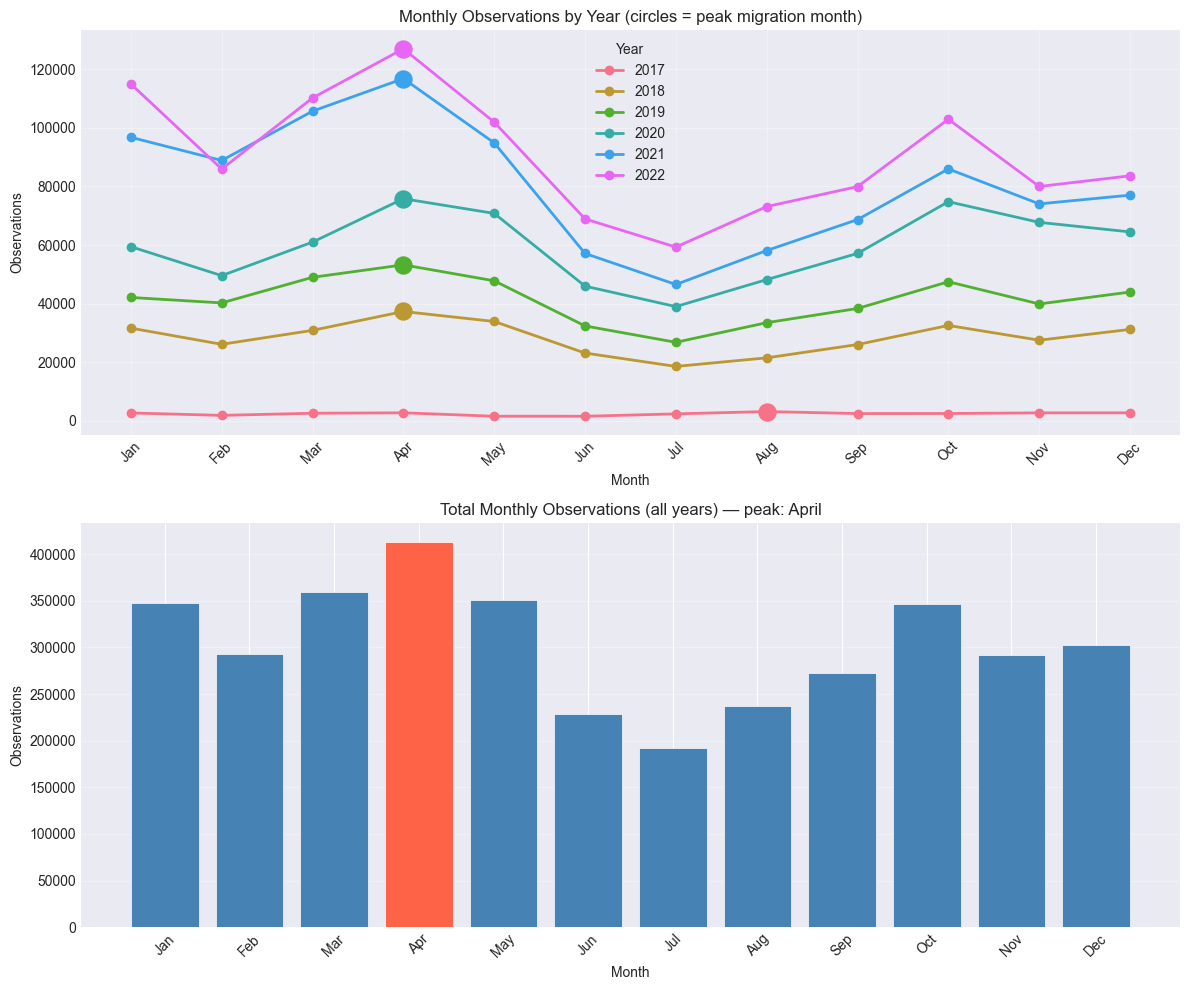

In [47]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').size().sort_index()
print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")

# Month each year
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

peak_months_by_year = {}  # store peak month per year

yearly_obs = combined_df.groupby('year').size().sort_index()
for year in yearly_obs.index:
    print("\nObservations by month of", int(year))
    monthly_obs = combined_df[combined_df['year'] == year].groupby('month').size().sort_index()
    for month, count in monthly_obs.items():
        if pd.notna(month):
            print(f"  {month_names[int(month)]}: {count:,}")
    
    # Save peak month for this year
    peak_month = monthly_obs.idxmax()
    if pd.notna(peak_month):
        peak_months_by_year[int(year)] = {
            'month': int(peak_month),
            'month_name': month_names[int(peak_month)],
            'count': monthly_obs.max()
        }
        print(f"  → Peak migration month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# By month (all years combined)
monthly_obs = combined_df.groupby('month').size().sort_index()
print("\nObservations by Month (all years):")
for month, count in monthly_obs.items():
    if pd.notna(month):
        print(f"  {month_names[int(month)]}: {count:,}")

# Peak observation period
peak_month = monthly_obs.idxmax()
if pd.notna(peak_month):
    print(f"\nPeak observation month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# Print summary of peak months
print("\nPeak Migration Month by Year:")
for year, info in peak_months_by_year.items():
    print(f"  {year}: {info['month_name']} ({info['count']:,} observations)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly observations per year (lines)
ax1 = axes[0]
for year in yearly_obs.index:
    if pd.notna(year):
        monthly = combined_df[combined_df['year'] == year].groupby('month').size().reindex(range(1, 13), fill_value=0)
        ax1.plot(range(1, 13), monthly.values, marker='o', label=str(int(year)), linewidth=2)
        # Mark peak month
        if int(year) in peak_months_by_year:
            pm = peak_months_by_year[int(year)]['month']
            ax1.scatter(pm, monthly[pm], s=150, zorder=5)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax1.set_title('Monthly Observations by Year (circles = peak migration month)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Observations')
ax1.legend(title='Year')
ax1.grid(True, alpha=0.3)

# Plot 2: Combined monthly observations (bar)
ax2 = axes[1]
colors = ['tomato' if m == int(peak_month) else 'steelblue' for m in range(1, 13)]
monthly_all = combined_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
bars = ax2.bar(range(1, 13), monthly_all.values, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax2.set_title(f'Total Monthly Observations (all years) — peak: {month_names[int(peak_month)]}')
ax2.set_xlabel('Month')
ax2.set_ylabel('Observations')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#print("\nPlot saved as 'temporal_analysis.png'")

In [48]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {row['observations']:,} observations | {row['number_of_birds']:,} number of birds counted")
        #print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
  2017: 29,046.0 observations | 70,070.0 number of birds counted
  2018: 340,439.0 observations | 879,417.0 number of birds counted
  2019: 494,781.0 observations | 1,303,126.0 number of birds counted
  2020: 713,935.0 observations | 1,887,300.0 number of birds counted
  2021: 970,514.0 observations | 2,590,803.0 number of birds counted
  2022: 1,087,847.0 observations | 2,812,169.0 number of birds counted


In [49]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        # print(f"  {int(year)}: {row['number_of_birds']:,} number of birds counted | {row['unique_observers']:,} unique observers")
        print(f"    Avg bird per observer: {(row['number_of_birds'] / row['unique_observers']):.2f}")
        # print(f"  {int(year)}: {row['observations']:,} observations | {row['unique_observers']:,} unique observers")
        print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
    Avg bird per observer: 19.69
    Avg obs per observer: 8.16
    Avg bird per observer: 90.83
    Avg obs per observer: 35.16
    Avg bird per observer: 102.75
    Avg obs per observer: 39.01
    Avg bird per observer: 147.32
    Avg obs per observer: 55.73
    Avg bird per observer: 164.81
    Avg obs per observer: 61.74
    Avg bird per observer: 128.07
    Avg obs per observer: 49.54


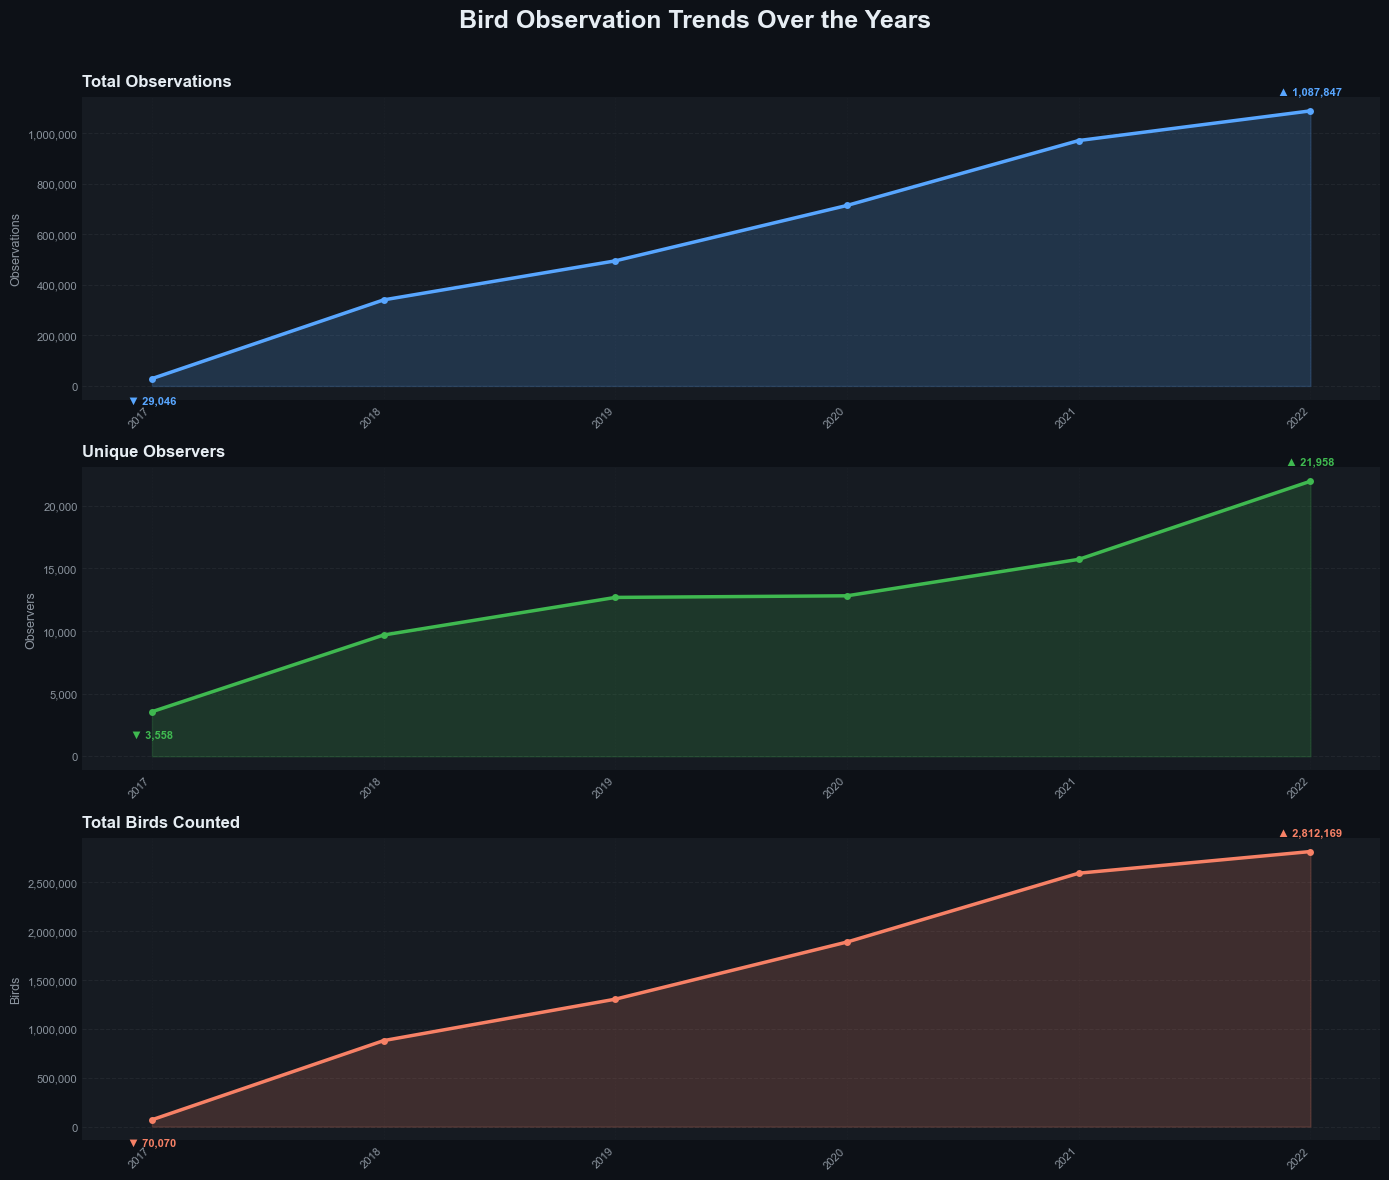

Plot saved to yearly_trends.png


In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor='#0d1117')
fig.suptitle('Bird Observation Trends Over the Years', 
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

years = yearly_obs.index.astype(int)

metrics = [
    ('observations',     '#58a6ff', 'Total Observations',     'Observations'),
    ('unique_observers', '#3fb950', 'Unique Observers',        'Observers'),
    ('number_of_birds',  '#f78166', 'Total Birds Counted',     'Birds'),
]

for ax, (col, color, title, ylabel) in zip(axes, metrics):
    values = yearly_obs[col].values

    ax.set_facecolor('#161b22')
    ax.fill_between(years, values, alpha=0.18, color=color)
    ax.plot(years, values, color=color, linewidth=2.5, marker='o',
            markersize=5, markerfacecolor=color, markeredgewidth=0)

    # Annotate min/max
    max_idx, min_idx = values.argmax(), values.argmin()
    for idx, label in [(max_idx, f'▲ {values[max_idx]:,.0f}'), 
                       (min_idx, f'▼ {values[min_idx]:,.0f}')]:
        ax.annotate(label, xy=(years[idx], values[idx]),
                    xytext=(0, 12 if idx == max_idx else -18),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_title(title, fontsize=12, color='#e6edf3', pad=8, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlim(years[0] - 0.3, years[-1] + 0.3)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.grid(axis='y', color='#21262d', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', color='#21262d', linewidth=0.4, linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Plot saved to yearly_trends.png")

### year and locality type

In [51]:
yearly_obs = combined_df.groupby('year').size().sort_index()

print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")
        locality_counts = (
            combined_df[combined_df['year'] == year]
            .groupby('LOCALITY TYPE')
            .size()
            .sort_values(ascending=False)
        )
        for locality, loc_count in locality_counts.items():
            print(f"    {locality}: {loc_count:,}")

        h = locality_counts.get('H', 0)
        p = locality_counts.get('P', 0)
        diff = h - p
        sign = "+" if diff > 0 else ""
        print(f"    H - P = {sign}{diff:,}")


Observations by Year:
  2017: 29,046
    H: 19,088
    P: 9,958
    H - P = +9,130
  2018: 340,439
    H: 196,396
    P: 144,043
    H - P = +52,353
  2019: 494,781
    H: 288,888
    P: 205,893
    H - P = +82,995
  2020: 713,935
    H: 404,332
    P: 309,603
    H - P = +94,729
  2021: 970,514
    H: 567,544
    P: 402,970
    H - P = +164,574
  2022: 1,087,847
    H: 656,963
    P: 430,884
    H - P = +226,079


### By Season

Analyzing bird sightings based on migration groups across different seasonal periods:
- **Spring Migration Period**: Mid-March to Mid-June
- **Summer Period**: July to Early August
- **Autumn Migration Period**: Late August to Early December  
- **Winter Period**: Late December to Early March

In [52]:
# Define seasonal periods
def get_season(date):
    """
    Classify observation date into seasonal periods.
    """
    if pd.isna(date):
        return 'Unknown'
    
    month = date.month
    day = date.day
    
    # Spring Migration: Mid-March (Mar 15) to Mid-June (Jun 15)
    if (month == 3 and day >= 15) or (month in [4, 5]) or (month == 6 and day <= 15):
        return 'Spring Migration (Mid-Mar to Mid-Jun)'
    
    # Summer: July and Early August (to Aug 20)
    elif month == 7 or (month == 8 and day <= 20):
        return 'Summer (Jul to Early Aug)'
    
    # Autumn Migration: Late August (Aug 21) to Early December (Dec 10)
    elif (month == 8 and day > 20) or (month in [9, 10, 11]) or (month == 12 and day <= 10):
        return 'Autumn Migration (Late Aug to Early Dec)'
    
    # Winter: Late December (Dec 11+) to Early March (Mar 14)
    else:  # (month == 12 and day > 10) or (month in [1, 2]) or (month == 3 and day < 15)
        return 'Winter (Late Dec to Early Mar)'

# Apply seasonal classification
combined_df['season'] = combined_df['obsDt'].apply(get_season)

print("Observations by season:")
season_counts = combined_df['season'].value_counts()
for season, count in season_counts.items():
    print(f"  {season}: {count:,} observations")

Observations by season:
  Winter (Late Dec to Early Mar): 1,102,248 observations
  Spring Migration (Mid-Mar to Mid-Jun): 1,101,832 observations
  Autumn Migration (Late Aug to Early Dec): 1,093,929 observations
  Summer (Jul to Early Aug): 338,553 observations


## 7. Distance to cities

In [53]:
# Load European cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
world = gpd.read_file(url)
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]
cities = europe[['NAME', 'ADM0NAME', 'geometry']].copy()
cities['lon'] = cities.geometry.x
cities['lat'] = cities.geometry.y
cities = cities.drop(columns='geometry').reset_index(drop=True)
cities

,NAME,ADM0NAME,lon,lat
0,L'Ariana,Tunisia,10.199998,36.866673
1,Jendouba,Tunisia,8.749999,36.500004
2,Kasserine,Tunisia,8.716698,35.216703
3,Sdid Bouzid,Tunisia,9.500004,35.016696
4,Siliana,Tunisia,9.383302,36.083304
...,...,...,...,...
1143,London,United Kingdom,-0.118668,51.501941
1144,Istanbul,Turkey,28.974277,41.017602
1145,Moscow,Russia,37.613577,55.754110
1146,Rome,Italy,12.481313,41.897902


In [54]:
cities['NAME'].unique()

array(["L'Ariana", 'Jendouba', 'Kasserine', ..., 'Moscow', 'Rome',
       'Paris'], shape=(1146,), dtype=object)

In [55]:
df_migratory = combined_df

In [56]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# build KD-Tree on city coordinates ---
# convert lat/lon to radians for accurate distance calculation
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# find closest city for each bird observation ---
birds_rad = np.radians(df_migratory[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# convert distance from radians to kilometers (Earth radius = 6371 km)
df_migratory['closest_city'] = cities['NAME'].iloc[indices].values
df_migratory['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_migratory['distance_km'] = np.round(distances * 6371, 2)

df_migratory

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,obsDt,year,month,day_of_week,day_of_year,howMany,season,closest_city,closest_city_country,distance_km
0,Great Spotted Woodpecker,Dendrocopos major,1.0,NaN,Portugal,PT,Portalegre,PT-12,Castelo de Vide,PT-12-CV,NaN,PN Serra de SÃ£o Mamede--Cana Flexa,L2939710,H,39.461957,-7.511044,2018-01-26,obsr429991,S42251764,Stationary,2018-01-26,2018,1,4,26,1.0,Winter (Late Dec to Early Mar),Portalegre,Portugal,21.48
1,Great Spotted Woodpecker,Dendrocopos major,1.0,NaN,Ukraine,UA,Kirovohrads'ka Oblast',UA-35,NaN,NaN,NaN,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,L8290442,P,49.052457,33.215695,2018-12-22,obsr1017757,S50893829,Traveling,2018-12-22,2018,12,5,356,1.0,Winter (Late Dec to Early Mar),Kremenchuk,Ukraine,24.04
2,Great Spotted Woodpecker,Dendrocopos major,3.0,NaN,Spain,ES,"Madrid, Comunidad de",ES-MD,NaN,NaN,NaN,LeganÃ©s--Parque Polvoranca,L4679861,H,40.325174,-3.796721,2018-01-21,obsr771146,S42131687,Traveling,2018-01-21,2018,1,6,21,3.0,Winter (Late Dec to Early Mar),Madrid,Spain,15.05
3,Great Spotted Woodpecker,Dendrocopos major,5.0,NaN,Croatia,HR,Koprivnicko-kriÅ¾evacka Å¾upanija,HR-06,NaN,NaN,NaN,Hill Crkvenjak,L4575501,P,46.092728,16.558564,2018-01-06,obsr733488,S41672345,Traveling,2018-01-06,2018,1,5,6,5.0,Winter (Late Dec to Early Mar),Zagreb,Croatia,70.12
4,Great Spotted Woodpecker,Dendrocopos major,2.0,NaN,United Kingdom,GB,Scotland,GB-SCT,Fife,GB-SCT-FIF,NaN,Kilrenny Common,L4811182,H,56.236498,-2.686082,2018-06-09,obsr407628,S46534187,Traveling,2018-06-09,2018,6,5,160,2.0,Spring Migration (Mid-Mar to Mid-Jun),Dundee,United Kingdom,43.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4039471,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,NaN,Gardens of Vatican City,L2281750,H,41.903587,12.450144,2022-04-09,obsr644609,S106631527,Stationary,2022-04-09,2022,4,5,99,1.0,Spring Migration (Mid-Mar to Mid-Jun),Vatican City,Vatican,0.36
4039472,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,NaN,Gardens of Vatican City,L2281750,H,41.903587,12.450144,2022-05-05,obsr112798,S108980796,Traveling,2022-05-05,2022,5,3,125,1.0,Spring Migration (Mid-Mar to Mid-Jun),Vatican City,Vatican,0.36
4039473,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,NaN,Gardens of Vatican City,L2281750,H,41.903587,12.450144,2022-10-07,obsr1771248,S120180143,Incidental,2022-10-07,2022,10,4,280,1.0,Autumn Migration (Late Aug to Early Dec),Vatican City,Vatican,0.36
4039474,European Robin,Erithacus rubecula,1.0,NaN,Vatican City (Holy See),VA,Vatican City (Holy See),VA-,NaN,NaN,NaN,Gardens of Vatican City,L2281750,H,41.903587,12.450144,2022-12-12,obsr988333,S123861665,Stationary,2022-12-12,2022,12,0,346,1.0,Winter (Late Dec to Early Mar),Vatican City,Vatican,0.36


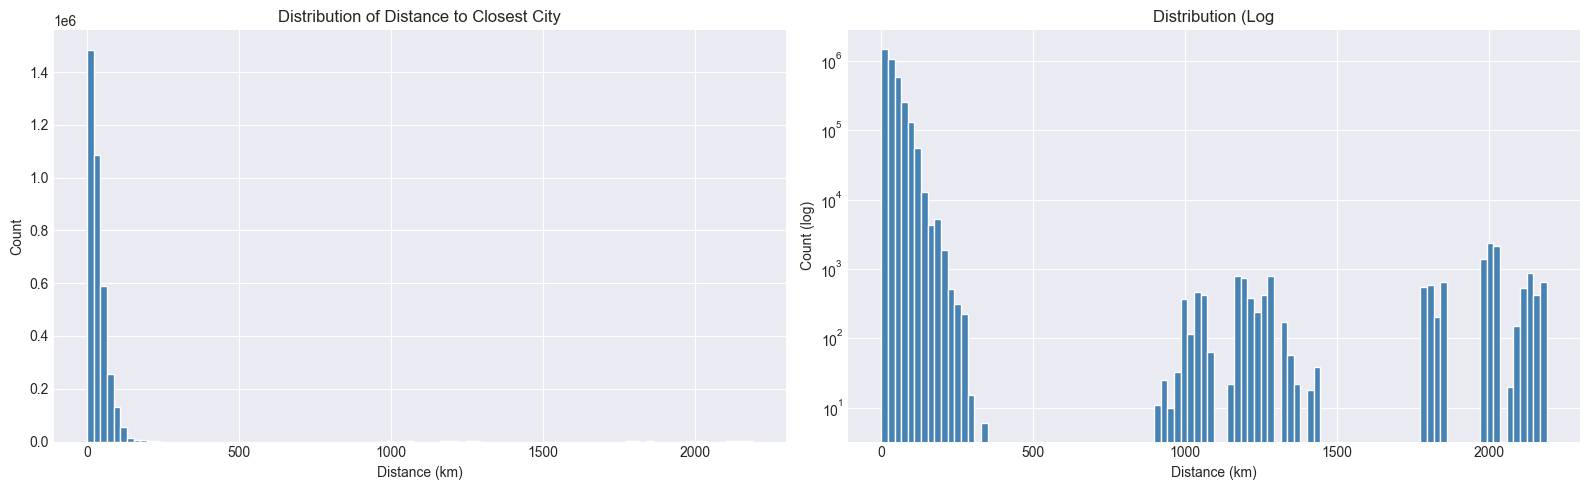

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

### Distance Aggregations

The following cells calculate the average distance to the closest city across three groupings:
1. **Per year** — how the average distance changes over time
2. **Per species** — average across all years for each species
3. **Per species per year** — the most granular breakdown

In [58]:
# --- 1. Average distance to closest city per year ---
dist_by_year = (
    df_migratory
    .dropna(subset=['distance_km', 'year'])
    .groupby('year')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('year')
)
dist_by_year['year'] = dist_by_year['year'].astype(int)

print("Average distance to closest city per year:")
print(dist_by_year.to_string(index=False))

Average distance to closest city per year:
 year  mean_distance_km  median_distance_km  n_observations
 2017         41.865980              32.825           29046
 2018         45.332769              28.570          340439
 2019         44.491083              28.860          494781
 2020         41.682730              27.000          713935
 2021         40.224726              27.090          970514
 2022         40.813832              28.290         1087847


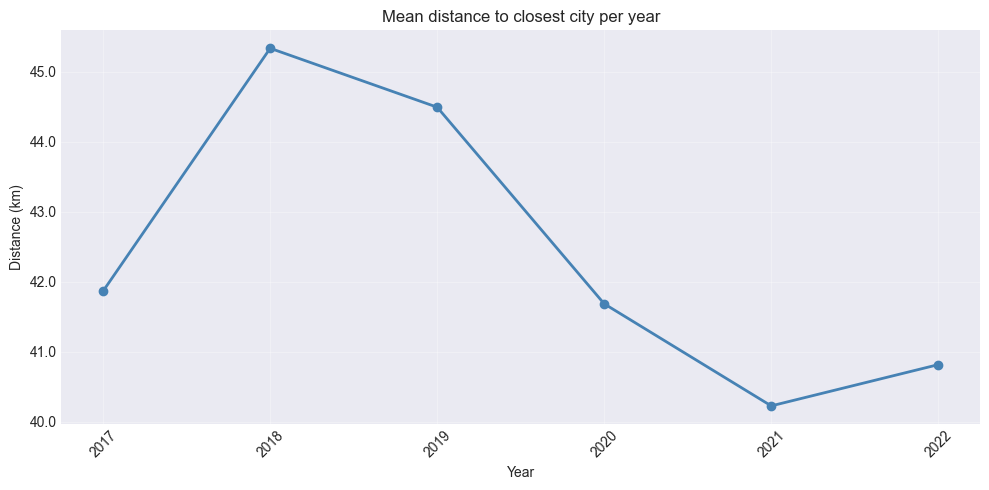

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dist_by_year['year'], dist_by_year['mean_distance_km'],
        color='steelblue', marker='o', linewidth=2, markersize=6)

ax.set_xticks(dist_by_year['year'])
ax.set_xticklabels(dist_by_year['year'], rotation=45)
ax.set_title('Mean distance to closest city per year')
ax.set_xlabel('Year')
ax.set_ylabel('Distance (km)')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

plt.tight_layout()
plt.show()

In [60]:
# --- 2. Average distance to closest city per species (across all years) ---
dist_by_species = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME'])
    .groupby('COMMON NAME')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('mean_distance_km', ascending=False)
)

print("Average distance to closest city per species (all years combined):")
print(dist_by_species.to_string(index=False))

Average distance to closest city per species (all years combined):
             COMMON NAME  mean_distance_km  median_distance_km  n_observations
          European Robin         52.405022               27.67         1318154
         Green Sandpiper         48.148268               35.56          173660
Great Spotted Woodpecker         37.344320               28.33          540408
      Eurasian Bullfinch         36.739426               30.29          187383
               Tawny Owl         36.679798               32.01           56752
               Great Tit         33.283635               26.24         1360205


In [61]:
# --- 3. Average distance to closest city per species per year ---
dist_by_species_year = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME', 'year'])
    .groupby(['COMMON NAME', 'year'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['COMMON NAME', 'year'])
)
dist_by_species_year['year'] = dist_by_species_year['year'].astype(int)

print("Average distance to closest city per species per year:")
print(dist_by_species_year.to_string(index=False))

# Optionally pivot for a cleaner species × year view
pivot_mean = dist_by_species_year.pivot(index='COMMON NAME', columns='year', values='mean_distance_km').round(2)
print("\nPivot table — mean distance (km) by species × year:")
print(pivot_mean.to_string())

Average distance to closest city per species per year:
             COMMON NAME  year  mean_distance_km  median_distance_km  n_observations
      Eurasian Bullfinch  2017         38.232048              31.670           14837
      Eurasian Bullfinch  2018         36.715234              30.500           16365
      Eurasian Bullfinch  2019         38.497512              31.270           23121
      Eurasian Bullfinch  2020         35.696529              29.350           34306
      Eurasian Bullfinch  2021         35.176339              29.060           48200
      Eurasian Bullfinch  2022         37.703139              31.030           50554
          European Robin  2018         59.248865              28.110          122784
          European Robin  2019         55.380458              28.130          182493
          European Robin  2020         52.627885              26.460          268015
          European Robin  2021         51.005221              27.095          350588
          

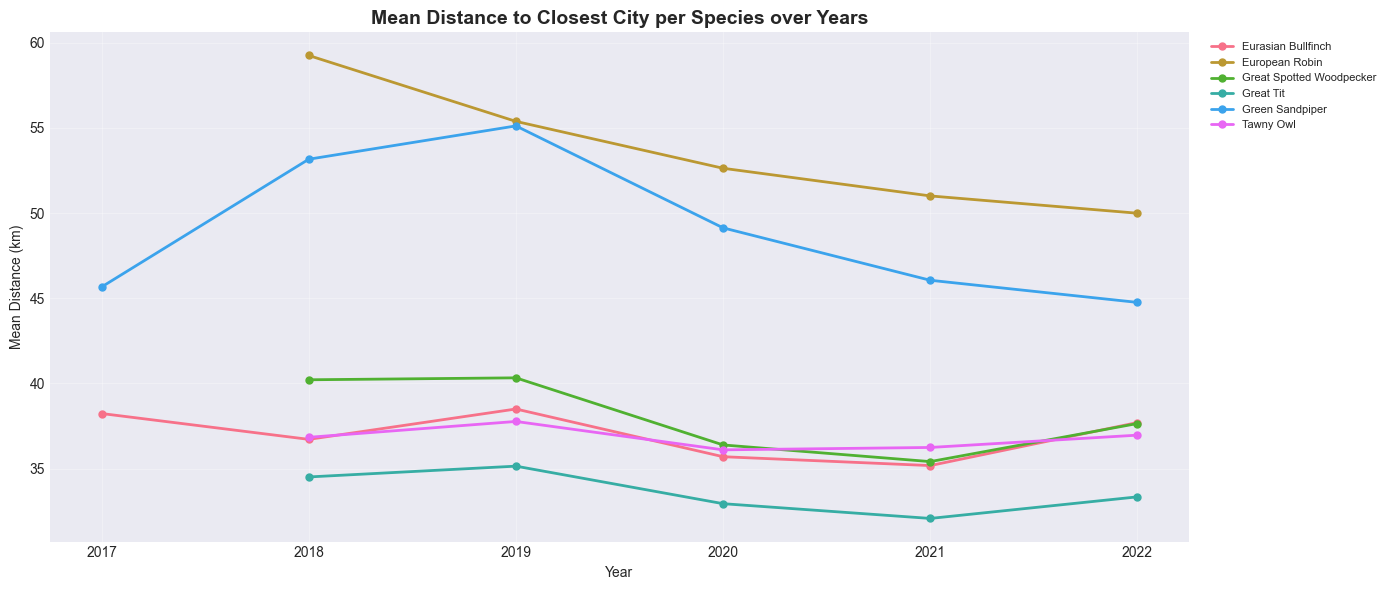

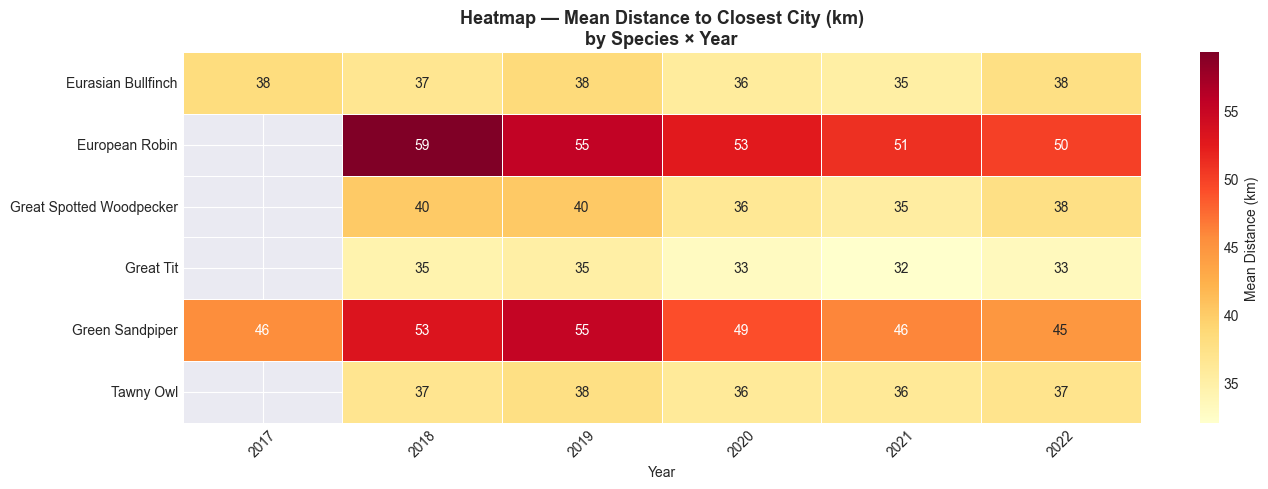

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Colour palette ──────────────────────────────────────────────────────────
species_list = dist_by_species_year['COMMON NAME'].unique()
palette = dict(zip(species_list, sns.color_palette("husl", len(species_list))))

# ============================================================
# PLOT 1 — Line plot: mean distance per species over years
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

for species, grp in dist_by_species_year.groupby('COMMON NAME'):
    ax.plot(grp['year'], grp['mean_distance_km'],
            marker='o', linewidth=2, markersize=5,
            label=species, color=palette[species])

ax.set_title('Mean Distance to Closest City per Species over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Distance (km)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist_species_year_lineplot.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2 — Heatmap: pivot_mean (species × year)
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(5, len(species_list) * 0.45)))

sns.heatmap(
    pivot_mean,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean Distance (km)'}
)

ax.set_title('Heatmap — Mean Distance to Closest City (km)\nby Species × Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('dist_species_year_heatmap.png', dpi=150)
plt.show()


In [63]:
print(df_migratory['distance_km'].describe())
print(f"\nMedian:  {df_migratory['distance_km'].median():.2f} km")
print(f"Skewness: {df_migratory['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_migratory['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_migratory['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_migratory['distance_km'] <= 100).mean()*100:.1f}%")

count    3.636562e+06
mean     4.175896e+01
std      1.178029e+02
min      2.000000e-02
25%      1.290000e+01
50%      2.788000e+01
75%      4.836000e+01
max      2.188640e+03
Name: distance_km, dtype: float64

Median:  27.88 km
Skewness: 14.78
% within 10km:  18.8%
% within 50km:  76.4%
% within 100km: 96.0%
